In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

In [3]:
def format_ticks(y, _):
        # Format with 2 decimals
        s = f'{y:.3f}'
        # Remove trailing zeros and dot if needed
        if '.' in s:
            s = s.rstrip('0').rstrip('.')
        # Remove leading zero before decimal point
        if s.startswith('0.') or s.startswith('-0.'):
            s = s.replace('0.', '.')
        return s

In [35]:
hierarchical = pd.read_csv("/home/wollerf/Projects/SignifiKANTE_Results.git/results/random_targets_wasserstein_all_tissues_with_samples.csv", index_col=0)
hierarchical = hierarchical[hierarchical["tissue"].isin(["Breast", "Kidney", "Testis"])]
hierarchical["Clustering method"] = "Hierarchical"

hierarchical_bh = pd.read_csv("/home/wollerf/Projects/SignifiKANTE_Results.git/results/random_targets_wasserstein_benjamini_hb_all_tissues.csv")
hierarchical_bh = hierarchical_bh[hierarchical_bh["tissue"].isin(["Breast", "Kidney", "Testis"])]
hierarchical_bh["Clustering method"] = "Hierarchical"


kmedoids = pd.read_csv("/home/wollerf/Projects/SignifiKANTE_Results.git/results/random_targets_grnboost_kmedoids_no_bh_results.csv")
kmedoids["Clustering method"] = "K-medoids"
kmedoids_bh  = pd.read_csv("/home/wollerf/Projects/SignifiKANTE_Results.git/results/random_targets_grnboost_kmedoids_with_bh_results.csv")
kmedoids_bh["Clustering method"] = "K-medoids"

spectral = pd.read_csv("/home/wollerf/Projects/SignifiKANTE_Results.git/results/random_targets_grnboost_spectral_no_bh_results.csv")
spectral["Clustering method"] = "Spectral"
spectral_bh = pd.read_csv("/home/wollerf/Projects/SignifiKANTE_Results.git/results/random_targets_grnboost_spectral_with_bh_results.csv")
spectral_bh["Clustering method"] = "Spectral"

with_bh = pd.concat([hierarchical_bh, kmedoids_bh, spectral_bh], ignore_index=True)
no_bh = pd.concat([hierarchical, kmedoids, spectral], ignore_index=True)
with_bh = with_bh.rename(columns={"tissue": "Tissue"})
no_bh = no_bh.rename(columns={"tissue": "Tissue"})


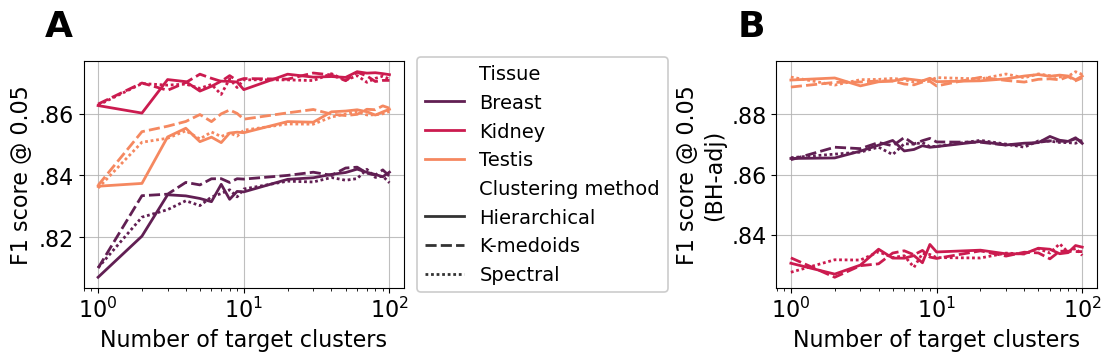

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ---------------------------------------------------------
# Figure layout:
# A | LEGEND | B
# ---------------------------------------------------------
fig, axs = plt.subplot_mosaic(
    [['A', 'LEG', 'B']],
    figsize=(11, 3.5),
    width_ratios=[1, 0.35, 1],
    constrained_layout=True
)

label_fontsize = 16
palette = sns.color_palette("rocket", 3)

# =========================================================
# PANEL A
# =========================================================
sns.lineplot(
    data=no_bh,
    x='num_non_tfs',
    y='f1_005',
    hue='Tissue',
    style='Clustering method',
    palette=palette,
    linewidth=2.0,
    ax=axs['A'],
    legend=False
)

axs['A'].set_xlabel(
    'Number of target clusters',
    fontsize=label_fontsize
)

axs['A'].set_ylabel(
    'F1 score @ 0.05',
    fontsize=label_fontsize
)

axs['A'].tick_params(axis='both', labelsize=label_fontsize)
axs['A'].grid(True, alpha=0.8)

axs['A'].set_xscale('log')

axs['A'].yaxis.set_major_formatter(
    FuncFormatter(format_ticks)
)

# =========================================================
# PANEL B
# =========================================================
sns.lineplot(
    data=with_bh,
    x='num_non_tfs',
    y='f1_005',
    hue='Tissue',
    style='Clustering method',
    palette=palette,
    linewidth=2.0,
    ax=axs['B'],
    legend='full'
)

axs['B'].set_xlabel(
    'Number of target clusters',
    fontsize=label_fontsize
)

axs['B'].set_ylabel(
    'F1 score @ 0.05\n(BH-adj)',
    fontsize=label_fontsize
)

axs['B'].tick_params(axis='both', labelsize=label_fontsize)
axs['B'].grid(True, alpha=0.8)

axs['B'].set_xscale('log')

axs['B'].yaxis.set_major_formatter(
    FuncFormatter(format_ticks)
)

# =========================================================
# CREATE CENTER LEGEND PANEL
# =========================================================

# Extract legend handles from panel B
handles, labels = axs['B'].get_legend_handles_labels()

# Remove duplicates
by_label = dict(zip(labels, handles))

# Turn off middle axis
axs['LEG'].axis('off')

# Put legend in center panel
legend = axs['LEG'].legend(
    by_label.values(),
    by_label.keys(),
    loc='center',
    title='',          # <- custom title
    frameon=True,            # <- add frame
    fontsize=label_fontsize - 2,
    title_fontsize=label_fontsize,
    ncol=1
)

# Optional frame styling
legend.get_frame().set_alpha(1.0)
legend.get_frame().set_linewidth(1.2)

# Remove original legend from B
if axs['B'].get_legend() is not None:
    axs['B'].get_legend().remove()

# =========================================================
# PANEL LABELS
# =========================================================
for key in ['A', 'B']:
    axs[key].text(
        -0.12,
        1.08,
        key,
        transform=axs[key].transAxes,
        fontsize=26,
        fontweight='bold',
        va='bottom',
        ha='left'
    )

#plt.show()

# Optional save
plt.savefig(
     "supplement_clustering_comparison.pdf",
     format='pdf',
     bbox_inches='tight'
)